# 06 — Results Visualization

Activation curves, confusion matrix, per-genre breakdown.

## Setup

In [10]:
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(".."))

from utils.label_conversion import CLASSES, convert_segments, convert_label
from utils.dataset import MELSPEC_DIR, SEGMENT_DIR
from utils.spectnt import SpecTNT
from utils.postprocessing import postprocess
from utils.target_generation import build_targets, TARGET_FPS, NATIVE_FPS
from utils.metrics import evaluate_song

device = torch.device("xpu" if torch.xpu.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"TARGET_FPS: {TARGET_FPS:.2f}")


Device: xpu
TARGET_FPS: 5.38


## Load a trained checkpoint and a test song

In [11]:
SAVE_DIR = "../checkpoints"
CKPT_PATH = os.path.join(SAVE_DIR, "spectnt_base_fold1.pt")
SID = "0095_firework"

model = SpecTNT().to(device)
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print(f"Loaded checkpoint: epoch {ckpt['epoch']}")
else:
    print("No checkpoint found, using untrained model (random)")
model.eval()


Loaded checkpoint: epoch 3


SpecTNT(
  (frontend): ResNetFrontEnd(
    (conv1): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
    (conv2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
    (conv3): Sequential(
      (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (blocks): ModuleList(
    (0-4): 5 x SpecTNTBlock(
      (spectral): SpectralEncoder(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96,

## Run inference on one song

In [12]:
def infer_full_song(model, sid):
    melspec = np.load(os.path.join(MELSPEC_DIR, f"{sid}-mel.npy"))
    total_native = melspec.shape[1]
    total_target = total_native // 4
    chunk_frames = 130

    all_b = np.zeros((total_target, 1), dtype=np.float32)
    all_f = np.zeros((total_target, 7), dtype=np.float32)
    counts = np.zeros(total_target, dtype=np.float32)

    hop = chunk_frames // 4
    for start in range(0, total_target - chunk_frames + 1, hop):
        native_start = start * 4
        native_end = native_start + chunk_frames * 4
        if native_end > total_native:
            break
        chunk = melspec[:, native_start:native_end]
        chunk_t = torch.from_numpy(chunk).unsqueeze(0).unsqueeze(0).float().to(device)
        with torch.no_grad():
            b, f = model(chunk_t)
        b = b.squeeze(0).cpu().numpy()
        f = f.squeeze(0).cpu().numpy()
        end = min(start + chunk_frames, total_target)
        seg_len = end - start
        all_b[start:end] += b[:seg_len]
        all_f[start:end] += f[:seg_len]
        counts[start:end] += 1

    mask = counts > 0
    all_b[mask] /= counts[mask, None]
    all_f[mask] /= counts[mask, None]
    return all_b, all_f, melspec

b_logits, f_logits, melspec = infer_full_song(model, SID)
print(f"Melspec: {melspec.shape}")
print(f"Boundary logits: {b_logits.shape}")
print(f"Function logits: {f_logits.shape}")


Melspec: (80, 3586)
Boundary logits: (896, 1)
Function logits: (896, 7)


## Load ground truth targets

In [13]:
boundaries_ref = [0.0]
labels_ref = []
with open(os.path.join(SEGMENT_DIR, f"{SID}.txt"), encoding="utf-8", errors="replace") as f:
    for line in f:
        parts = line.strip().split(maxsplit=1)
        if len(parts) == 2:
            boundaries_ref.append(float(parts[0]))
            labels_ref.append(parts[1].strip())

conv_labels, _ = convert_segments(boundaries_ref[:-1], labels_ref)
print(f"Ground truth: {list(zip(boundaries_ref, [''] + conv_labels))}")

# Get predicted boundaries and labels
boundaries_pred, labels_pred, _ = postprocess(
    b_logits.squeeze(-1), f_logits, fps=TARGET_FPS,
)
print(f"Predicted: {list(zip(boundaries_pred, labels_pred))}")

if len(boundaries_pred) > 1 and len(boundaries_ref) > 1 and len(labels_pred) > 0 and len(conv_labels) > 0:
    metrics = evaluate_song(boundaries_pred, labels_pred, boundaries_ref, conv_labels)
    print(f"\nMetrics: {metrics}")


Ground truth: [(0.0, ''), (0.0, 'intro'), (7.741376, 'verse'), (37.257446, 'verse'), (53.225156, 'chorus'), (85.160576, 'verse'), (115.160516, 'chorus'), (147.095936, 'bridge'), (162.579776, 'end')]
Predicted: [(0.0, 'verse'), (np.float64(7.616145124716553), 'chorus'), (np.float64(12.445895691609977), 'chorus'), (np.float64(22.66267573696145), 'chorus'), (np.float64(28.23546485260771), 'chorus'), (np.float64(29.164263038548754), 'chorus'), (np.float64(38.080725623582765), 'chorus'), (np.float64(53.127256235827666), 'chorus'), (np.float64(69.28834467120181), 'chorus'), (np.float64(80.43392290249433), 'chorus'), (np.float64(85.26367346938775), 'chorus'), (np.float64(105.13995464852607), 'chorus'), (np.float64(107.740589569161), 'chorus'), (np.float64(116.28553287981859), 'chorus'), (np.float64(126.68807256235827), 'chorus'), (np.float64(131.14630385487527), 'chorus'), (np.float64(161.61088435374148), 'intro')]

Metrics: {'hr.5f': 0.3846153846153846, 'pwf': 0.449659027221401, 'sf': 0.0720

## Paper-style activation curve plot

C:\Users\shaik53\AppData\Local\Temp\ipykernel_20300\898735809.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


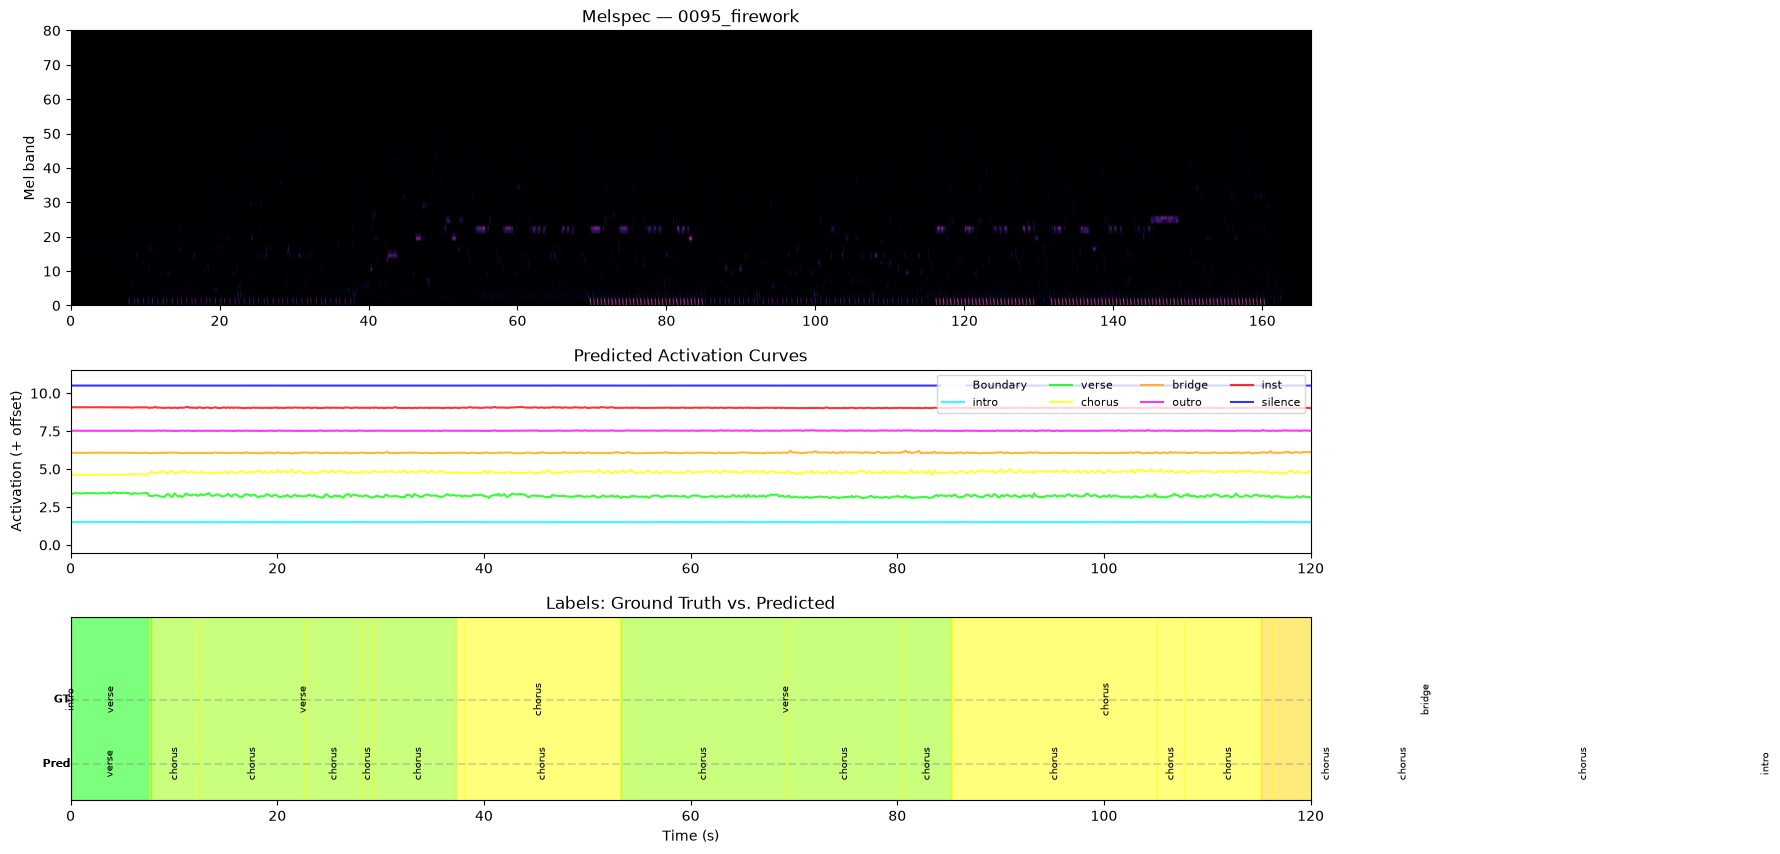

In [14]:
colors = ["cyan", "lime", "yellow", "orange", "magenta", "red", "blue"]

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 1, height_ratios=[1.5, 1, 1], hspace=0.3)

# Top: mel spectrogram
ax0 = fig.add_subplot(gs[0])
native_time = np.arange(melspec.shape[1]) / NATIVE_FPS
ax0.imshow(melspec, aspect="auto", origin="lower",
          extent=[0, native_time[-1], 0, 80], cmap="magma")
ax0.set_ylabel("Mel band")
ax0.set_title(f"Melspec — {SID}")

# Middle: activation curves
ax1 = fig.add_subplot(gs[1])
target_time = np.arange(len(b_logits)) / TARGET_FPS
b_probs = 1 / (1 + np.exp(-b_logits.squeeze(-1)))
ax1.plot(target_time, b_probs, "w-", linewidth=2, label="Boundary")
for i, cls_name in enumerate(CLASSES):
    f_probs = 1 / (1 + np.exp(-f_logits[:, i]))
    ax1.plot(target_time, f_probs + (i + 1) * 1.5, color=colors[i],
             label=cls_name, alpha=0.8)
ax1.set_ylabel("Activation (+ offset)")
ax1.set_xlim(0, min(120, native_time[-1]))
ax1.legend(loc="upper right", ncol=4, fontsize=8)
ax1.set_title("Predicted Activation Curves")

# Bottom: labels
ax2 = fig.add_subplot(gs[2])
# Ground truth
for i in range(len(boundaries_ref) - 1):
    s, e = boundaries_ref[i], boundaries_ref[i+1]
    cls_idx = CLASSES.index(conv_labels[i]) if conv_labels[i] in CLASSES else -1
    if cls_idx >= 0:
        ax2.axvspan(s, e, alpha=0.3, color=colors[cls_idx])
        ax2.text((s+e)/2, 0.55, conv_labels[i], ha="center", va="center",
                fontsize=7, rotation=90)
ax2.axhline(0.55, color="gray", linestyle="--", alpha=0.3)
ax2.text(0, 0.55, "GT", ha="right", va="center", fontsize=8, fontweight="bold")

# Predictions
for i in range(len(boundaries_pred) - 1):
    s, e = boundaries_pred[i], boundaries_pred[i+1]
    cls_idx = CLASSES.index(labels_pred[i]) if labels_pred[i] in CLASSES else -1
    if cls_idx >= 0:
        ax2.axvspan(s, e, alpha=0.3, color=colors[cls_idx])
        ax2.text((s+e)/2, 0.2, labels_pred[i], ha="center", va="center",
                fontsize=7, rotation=90)
ax2.axhline(0.2, color="gray", linestyle="--", alpha=0.3)
ax2.text(0, 0.2, "Pred", ha="right", va="center", fontsize=8, fontweight="bold")

ax2.set_xlabel("Time (s)")
ax2.set_xlim(0, min(120, native_time[-1]))
ax2.set_ylim(0, 1)
ax2.set_title("Labels: Ground Truth vs. Predicted")
ax2.set_yticks([])

plt.tight_layout()
plt.show()


## Confusion matrix

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def compute_confusion_matrix(model, val_ids):
    y_true = []
    y_pred = []
    for sid in val_ids:
        try:
            b_logits, f_logits, _ = infer_full_song(model, sid)
            boundaries_pred, labels_pred, _ = postprocess(b_logits.squeeze(-1), f_logits, fps=TARGET_FPS)

            boundaries_ref = [0.0]
            labels_ref = []
            with open(os.path.join(SEGMENT_DIR, f"{sid}.txt"), encoding="utf-8", errors="replace") as f:
                for line in f:
                    parts = line.strip().split(maxsplit=1)
                    if len(parts) == 2:
                        boundaries_ref.append(float(parts[0]))
                        labels_ref.append(parts[1].strip())
            conv_labels, _ = convert_segments(boundaries_ref[:-1], labels_ref)

            y_true.extend(conv_labels)
            y_pred.extend(labels_pred[:len(conv_labels)])
        except:
            pass
    return y_true, y_pred

# y_true, y_pred = compute_confusion_matrix(model, [SID])
print("(Requires trained model and more songs)")


(Requires trained model and more songs)


## Per-genre breakdown

In [16]:
import pandas as pd
meta = pd.read_csv(os.path.abspath("../data/harmonixset/dataset/metadata.csv"),
                   encoding="utf-8", encoding_errors="replace")
print("Genre counts:")
print(meta["Genre"].value_counts())


Genre counts:
Genre
Pop                 422
Hip-Hop             140
Dance/Electronic    129
Country              39
Rock                 36
Alternative          33
Metal                32
R&B                  25
Reggaeton            15
Funk/Disco           14
Classic Rock          8
Grunge                6
Prog                  5
Blues                 2
Indie Rock            2
Pop-Rock              1
World                 1
Punk                  1
Name: count, dtype: int64


## Smoothing Comparison on a Single Song

Compare baseline (peak-picking + segment argmax) vs. Viterbi-smoothed labels.

In [17]:
from utils.smoothing import compute_transition_matrix, smoothed_postprocess
from utils.metrics import evaluate_song

# Compute transition matrix from all training IDs
META_PATH = os.path.abspath("../data/harmonixset/dataset/metadata.csv")
meta = pd.read_csv(META_PATH, encoding="utf-8", encoding_errors="replace")
all_ids = meta["File"].tolist()
trans_mat = compute_transition_matrix(all_ids, SEGMENT_DIR, self_loop_prior=50.0)

# Run both postprocessors inline
boundaries_base, labels_base, _ = postprocess(
    b_logits.squeeze(-1), f_logits, fps=TARGET_FPS,
)
boundaries_smo, labels_smo, _ = smoothed_postprocess(
    b_logits.squeeze(-1), f_logits, trans_mat, fps=TARGET_FPS,
)

if len(boundaries_smo) > 1 and len(boundaries_ref) > 1:
    metrics_base = evaluate_song(boundaries_base, labels_base, boundaries_ref, conv_labels)
    metrics_smo = evaluate_song(boundaries_smo, labels_smo, boundaries_ref, conv_labels)
    print(f"Baseline metrics: {metrics_base}")
    print(f"Smoothed metrics: {metrics_smo}")


Baseline metrics: {'hr.5f': 0.3846153846153846, 'pwf': 0.449659027221401, 'sf': 0.07207975661997647, 'acc': 0.33025830258302585, 'macro_f1': 0.09432286828905813}
Smoothed metrics: {'hr.5f': 0.3846153846153846, 'pwf': 0.4388556477054417, 'sf': 0.1039389796538708, 'acc': 0.35977859778597787, 'macro_f1': 0.11104414677563142}


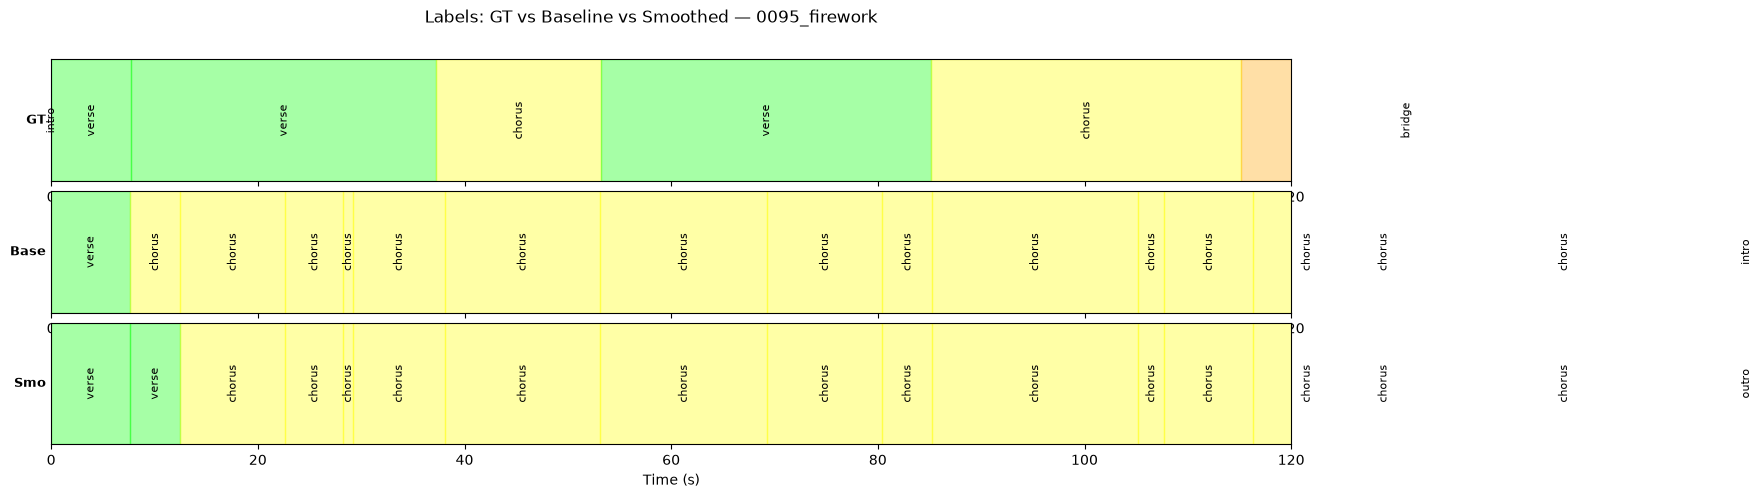


Statistic                 GT           Baseline     Smoothed    
-------------------------------------------------------------
Num segments              8            17           17          
Median seg dur (s)        22.7         8.5          8.5         
Transition rate (/s)      0.043        0.096        0.096       
HR@0.5                    0.3846       0.3846      


In [18]:
# Three-way comparison: GT vs Baseline vs Smoothed
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(3, 1, hspace=0.08)

colors = ["cyan", "lime", "yellow", "orange", "magenta", "red", "blue"]
xlim = min(120, native_time[-1])

def draw_row(ax, boundaries, labels, y, label):
    ax.set_ylim(0, 1)
    ax.set_xlim(0, xlim)
    ax.set_yticks([])
    for k in range(len(boundaries) - 1):
        s, e = boundaries[k], boundaries[k+1]
        idx = CLASSES.index(labels[k]) if labels[k] in CLASSES else -1
        if idx >= 0:
            ax.axvspan(s, e, alpha=0.35, color=colors[idx])
            ax.text((s+e)/2, 0.5, labels[k], ha="center", va="center",
                    fontsize=8, rotation=90)
    ax.text(-0.5, 0.5, label, ha="right", va="center", fontsize=9, fontweight="bold")

ax0 = fig.add_subplot(gs[0])
draw_row(ax0, boundaries_ref, conv_labels, 0.5, "GT")

ax1 = fig.add_subplot(gs[1], sharex=ax0)
draw_row(ax1, boundaries_base, labels_base, 0.5, "Base")

ax2 = fig.add_subplot(gs[2], sharex=ax0)
draw_row(ax2, boundaries_smo, labels_smo, 0.5, "Smo")
ax2.set_xlabel("Time (s)")

fig.suptitle(f"Labels: GT vs Baseline vs Smoothed \u2014 {SID}", fontsize=12)
plt.show()

# Temporal consistency table
print(f"\n{'Statistic':<25} {'GT':<12} {'Baseline':<12} {'Smoothed':<12}")
print(f"{'-'*61}")
print(f"{'Num segments':<25} {len(conv_labels):<12} {len(labels_base):<12} {len(labels_smo):<12}")
gt_durs = [boundaries_ref[i+1] - boundaries_ref[i] for i in range(len(boundaries_ref)-1)]
base_durs = [boundaries_base[i+1] - boundaries_base[i] for i in range(len(boundaries_base)-1)]
smo_durs = [boundaries_smo[i+1] - boundaries_smo[i] for i in range(len(boundaries_smo)-1)]
print(f"{'Median seg dur (s)':<25} {np.median(gt_durs):<12.1f} {np.median(base_durs):<12.1f} {np.median(smo_durs):<12.1f}")
print(f"{'Transition rate (/s)':<25} {(len(conv_labels)-1)/boundaries_ref[-1]:<12.3f} {(len(labels_base)-1)/boundaries_base[-1]:<12.3f} {(len(labels_smo)-1)/boundaries_smo[-1]:<12.3f}")
print(f"{'HR@0.5':<25} {metrics_base['hr.5f']:<12.4f} {metrics_smo['hr.5f']:<12.4f}")
